# Домашнее задание: RAG по созвездиям + Image-RAG

**Часть 1 (7 баллов):** текстовый RAG по статьям Wikipedia о созвездиях с Qwen.

**Часть 2 (3 балла):** мультимодальный RAG, который отвечает на вопросы по картинке через BLIP captioning + текстовый RAG.

**Общая задача:** построить RAG систему на основе статей Wiki, которая сможет отвечать на вопросы о созвездиях, а также о различных изображениях, где встречаются отсылки к созвездиям. В идеале система должна быть способна отвечать как на специфичные вопросы, касающиеся размера, количества звезд в созвездии, так и на простые (например, "Какие созвездия включают в себя изображения человека?")

Ссылка для сдачи ДЗ: https://forms.gle/NH7m25G6X9qYX7j38

## 0. Установка зависимостей

In [ ]:
!pip install -q 'numpy<2'
!pip install -q wikipedia-api
!pip install -q langchain langchain-community langchain-huggingface
!pip install -q chromadb
!pip install -q sentence-transformers
!pip install -q transformers accelerate
!pip install -q pillow

import os
os.kill(os.getpid(), 9)

In [6]:
import os
import re
import warnings  # чтобы заглушить лишние предупреждения
import logging  # для логирования MultiQueryRetriever
from typing import List, Dict, Tuple
from pprint import pprint

import numpy as np

In [2]:
warnings.filterwarnings('ignore')
# Отключаем телеметрию ChromaDB
os.environ['ANONYMIZED_TELEMETRY'] = 'False'
# Отключаем параллелизм токенизаторов, чтобы не было предупреждений после fork()
os.environ['TOKENIZERS_PARALLELISM'] = 'false'

---
# Часть 1. Текстовый RAG по созвездиям (7 баллов)

Мы построим RAG-систему, которая отвечает на вопросы о созвездиях, опираясь на статьи Wikipedia.

Pipeline стандартный: **парсинг → чанкинг → эмбеддинги → векторное хранилище → retrieval → генерация**.

## 1.1. Парсинг Wikipedia (1 балл)

Необходимо скачать английские статьи через `wikipedia-api` о созвездиях. API сам отдаёт чистый текст без вики-разметки.


In [3]:
import wikipediaapi  # клиент к Wikipedia API

# Создаём клиент с user-agent, Wikipedia требует его указывать
wiki = wikipediaapi.Wikipedia(
    user_agent='RAG-Homework/1.0 (educational)',  # идентификатор
    language='en',  # английская Wikipedia
    extract_format=wikipediaapi.ExtractFormat.WIKI  # вернёт plain-text без HTML
)


# переопределяем CONSTELLATIONS как словарь
CONSTELLATIONS = {
    "Orion": "Orion (constellation)",
    "Scorpius": "Scorpius",
    "Ursa Major": "Ursa Major",
    "Cassiopeia": "Cassiopeia (constellation)",
    "Leo": "Leo (constellation)",
    "Cygnus": "Cygnus (constellation)",
    "Gemini": "Gemini (constellation)",
    "Aquarius": "Aquarius (constellation)",
    "Perseus": "Perseus (constellation)",
    "Virgo": "Virgo (constellation)",
    "Andromeda": "Andromeda (constellation)",
    "Pegasus": "Pegasus (constellation)",
    "Hercules": "Hercules (constellation)"
}


def fetch_wiki_article(page_title: str) -> str:
    """Скачивает текст статьи Wikipedia и аккуратно обрабатывает ошибки."""
    # Запрашиваем страницу
    page = wiki.page(page_title)
    # Проверяем существование страницы
    if not page.exists():
        # Прописываем исключение
        raise ValueError(f"Страница '{page_title}' не найдена в Wikipedia")
    text = page.text
    # Убираем повторяющиеся переводы строк
    text = re.sub(r'\n{3,}', '\n\n', text)
    return text

#ВАШ КОД
# Качаем статьи по всем созвездиям с помощью функции fetch_wiki_articles, сохраняем в словарь articles
articles = {}
for short_name, page_title in CONSTELLATIONS.items():
    try:
        articles[short_name] = fetch_wiki_article(page_title)
        print(f"OK: {short_name:12s} | {len(articles[short_name]):6d} symbols | source: {page_title}")
    except Exception as e:
        print(f"ERROR: {short_name} ({page_title}): {e}")

print(f"\nDownloaded articles: {len(articles)} / {len(CONSTELLATIONS)}")

OK: Orion        |  25753 symbols | source: Orion (constellation)
OK: Scorpius     |   6139 symbols | source: Scorpius
OK: Ursa Major   |  20447 symbols | source: Ursa Major
OK: Cassiopeia   |  20265 symbols | source: Cassiopeia (constellation)
OK: Leo          |   7910 symbols | source: Leo (constellation)
OK: Cygnus       |  22896 symbols | source: Cygnus (constellation)
OK: Gemini       |  11619 symbols | source: Gemini (constellation)
OK: Aquarius     |  17008 symbols | source: Aquarius (constellation)
OK: Perseus      |  18060 symbols | source: Perseus (constellation)
OK: Virgo        |   9930 symbols | source: Virgo (constellation)
OK: Andromeda    |  19885 symbols | source: Andromeda (constellation)
OK: Pegasus      |  14209 symbols | source: Pegasus (constellation)
OK: Hercules     |  16173 symbols | source: Hercules (constellation)

Downloaded articles: 13 / 13


In [4]:
# Смотрим первые 500 символов каждой статьи, чтобы удостовериться, что все верно
for name, text in articles.items():
    print(f'=== {name} ===')
    print(text[:500])
    print('...\n')

=== Orion ===
Orion is a prominent set of stars visible during winter in the northern celestial hemisphere. It is one of the 88 modern constellations; it was among the 48 constellations listed by the 2nd-century AD astronomer Ptolemy. It is named after a hunter in Greek mythology.
Orion is most prominent during winter evenings in the Northern Hemisphere, as are five other constellations that have stars in the Winter Hexagon asterism. Orion's two brightest stars, Rigel (β) and Betelgeuse (α), are both among th
...

=== Scorpius ===
Scorpius is a zodiac constellation located in the Southern celestial hemisphere, where it sits near the center of the Milky Way, between Libra to the west and Sagittarius to the east. Scorpius is an ancient constellation whose recognition predates Greek culture; it is one of the 48 constellations identified by the Greek astronomer Ptolemy in the second century.

Features
Stars
Scorpius contains many bright stars, including Antares (α Sco), "rival of Mars," so

## 1.2. Сравнение двух стратегий чанкования (3 балла)

В RAG способ разбиения текста на куски (чанки) напрямую влияет на качество retrieval. Сравним два сплиттера из LangChain:

- **`CharacterTextSplitter`** - режет по одному разделителю (по умолчанию `\n\n`). Простой, но может выдать слишком длинные или слишком короткие куски, если разделитель распределён неравномерно.
- **`RecursiveCharacterTextSplitter`** - пробует разделители по списку (от `\n\n` к `\n` к ` ` к ``). Это даёт более ровный размер чанков и сохраняет смысловые границы.

Необходимо в этой части:
*   дописать функцию для подсчета простой статистики для сравнения чанкеров - 0,5 балла
*   проанализировать 2 вида чанкеров с разными параметрами и ответить на поставленные вопросы- 2 балла
*   реализовать отдельную функцию для сравнения чанкеров - 0,5 балла





In [7]:
from langchain_text_splitters import CharacterTextSplitter, RecursiveCharacterTextSplitter
# Параметры одинаковые для обоих, чтобы сравнение было честным
CHUNK_SIZE = 800  # целевой размер чанка в символах
CHUNK_OVERLAP = 100  # перекрытие помогает не терять контекст на границах

char_splitter = CharacterTextSplitter(
    separator='\n\n',  # единственный разделитель
    chunk_size=CHUNK_SIZE,
    chunk_overlap=CHUNK_OVERLAP,
    length_function=len,  # считаем длину в символах, а не в токенах
)

recursive_splitter = RecursiveCharacterTextSplitter(
    separators=['\n\n', '\n', '. ', ' ', ''],  # от смысловых границ к посимвольным
    chunk_size=CHUNK_SIZE,
    chunk_overlap=CHUNK_OVERLAP,
    length_function=len,
)

# Берём для сравнения текст про Орион
sample_text = articles['Orion']

# Применяем оба сплиттера к одному и тому же тексту
char_chunks = char_splitter.split_text(sample_text)
recursive_chunks = recursive_splitter.split_text(sample_text)

# Напишите функцию для подсчета простой статистики: количество кусков, средняя/мин/макс длина
def chunk_stats(chunks: List[str]) -> Dict[str, float]:
    lengths = [len(chunk) for chunk in chunks]
    if not lengths:
        return {
            'n_chunks': 0,
            'mean_len': 0,
            'median_len': 0,
            'min_len': 0,
            'max_len': 0,
            'std_len': 0,
        }
    return {
        'n_chunks': len(lengths),
        'mean_len': round(float(np.mean(lengths)), 2),
        'median_len': round(float(np.median(lengths)), 2),
        'min_len': int(np.min(lengths)),
        'max_len': int(np.max(lengths)),
        'std_len': round(float(np.std(lengths)), 2),
    }
print('CharacterTextSplitter:', chunk_stats(char_chunks))
print('RecursiveCharacterTextSplitter:', chunk_stats(recursive_chunks))

CharacterTextSplitter: {'n_chunks': 23, 'mean_len': 1118.48, 'median_len': 792.0, 'min_len': 370, 'max_len': 3029, 'std_len': 755.14}
RecursiveCharacterTextSplitter: {'n_chunks': 51, 'mean_len': 503.96, 'median_len': 491.0, 'min_len': 4, 'max_len': 797, 'std_len': 208.07}


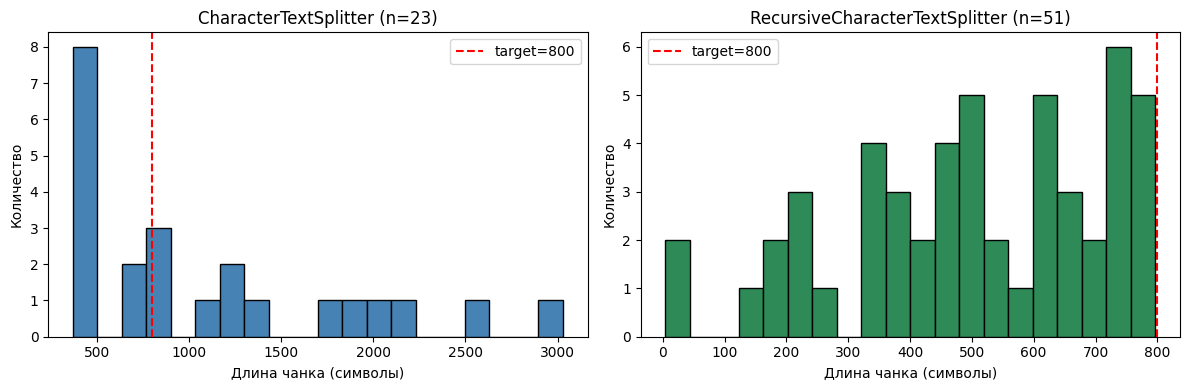

In [8]:
# Визуальное сравнение: рисуем гистограмму длин для обоих сплиттеров рядом
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Гистограмма длин для CharacterTextSplitter
axes[0].hist([len(c) for c in char_chunks], bins=20, color='steelblue', edgecolor='black')
axes[0].set_title(f'CharacterTextSplitter (n={len(char_chunks)})')
axes[0].set_xlabel('Длина чанка (символы)')
axes[0].set_ylabel('Количество')
# Вертикальная линия на целевом размере. Так мы увидим, насколько сплиттер от него отклоняется
axes[0].axvline(CHUNK_SIZE, color='red', linestyle='--', label=f'target={CHUNK_SIZE}')
axes[0].legend()

# Гистограмма для RecursiveCharacterTextSplitter
axes[1].hist([len(c) for c in recursive_chunks], bins=20, color='seagreen', edgecolor='black')
axes[1].set_title(f'RecursiveCharacterTextSplitter (n={len(recursive_chunks)})')
axes[1].set_xlabel('Длина чанка (символы)')
axes[1].set_ylabel('Количество')
axes[1].axvline(CHUNK_SIZE, color='red', linestyle='--', label=f'target={CHUNK_SIZE}')
axes[1].legend()

plt.tight_layout()
plt.show()

### TO DO

Поэкспериментируйте со сплиттерами. В ячейке ниже сравните, как меняется распределение длин чанков при разных значениях `chunk_size` (например, 400 vs 800 vs 1600) и `chunk_overlap` (0 vs 100 vs 300).

**Ответьте на следующие вопросы:**
1. Какой сплиттер вы бы выбрали для дальнейшей работы и почему?
2. При каких `chunk_size` и `chunk_overlap` распределение выглядит самым ровным?
3. Что произойдёт с retrieval, если поставить `chunk_size=100`? А `chunk_size=4000`?

,splitter,chunk_size,chunk_overlap,n_chunks,mean_len,median_len,min_len,max_len,std_len
0,CharacterTextSplitter,400,0,27,951.89,564.0,14,3029,789.74
2,CharacterTextSplitter,400,100,27,951.89,564.0,14,3029,789.74
4,CharacterTextSplitter,400,300,27,951.89,564.0,14,3029,789.74
6,CharacterTextSplitter,800,0,23,1117.78,792.0,370,3029,755.74
8,CharacterTextSplitter,800,100,23,1118.48,792.0,370,3029,755.14
10,CharacterTextSplitter,800,300,23,1129.83,792.0,370,3029,746.03
12,CharacterTextSplitter,1600,0,17,1513.00,1358.0,415,3029,669.58
14,CharacterTextSplitter,1600,100,17,1513.94,1358.0,415,3029,668.11
16,CharacterTextSplitter,1600,300,17,1524.47,1358.0,415,3029,660.77
1,RecursiveCharacterTextSplitter,400,0,108,237.53,267.0,4,394,118.06


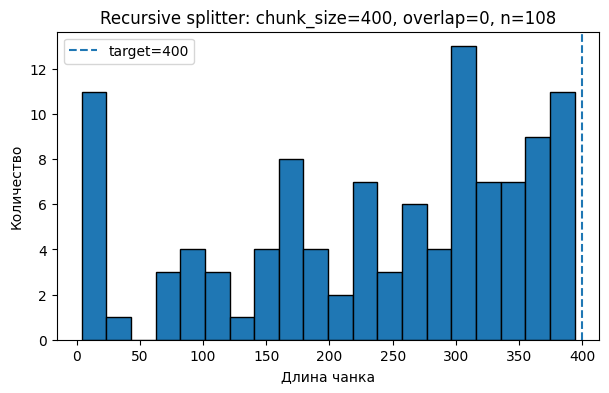

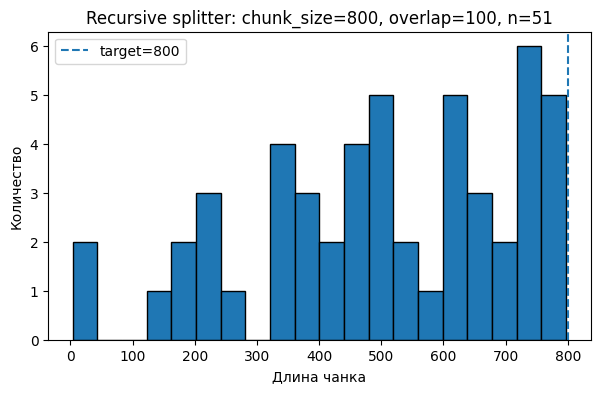

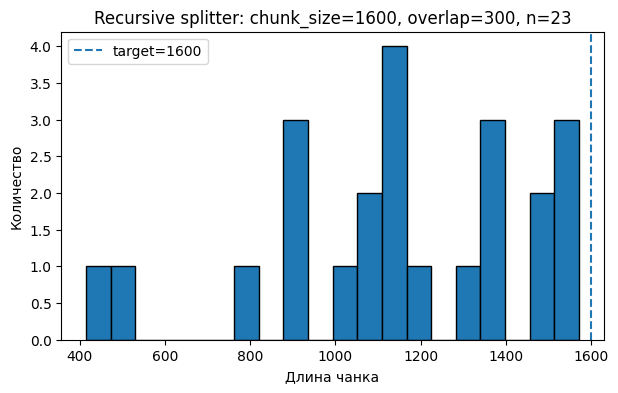

In [9]:
import pandas as pd
import matplotlib.pyplot as plt

def compare_chunkers(
    text: str,
    chunk_sizes=(400, 800, 1600),
    chunk_overlaps=(0, 100, 300),
) -> pd.DataFrame:
    """Сравнивает CharacterTextSplitter и RecursiveCharacterTextSplitter на разных параметрах."""
    rows = []
    for chunk_size in chunk_sizes:
        for chunk_overlap in chunk_overlaps:
            # overlap должен быть меньше chunk_size, иначе LangChain выдаст ошибку
            if chunk_overlap >= chunk_size:
                continue

            splitters = {
                'CharacterTextSplitter': CharacterTextSplitter(
                    separator='\n\n',
                    chunk_size=chunk_size,
                    chunk_overlap=chunk_overlap,
                    length_function=len,
                ),
                'RecursiveCharacterTextSplitter': RecursiveCharacterTextSplitter(
                    separators=['\n\n', '\n', '. ', ' ', ''],
                    chunk_size=chunk_size,
                    chunk_overlap=chunk_overlap,
                    length_function=len,
                ),
            }

            for splitter_name, splitter in splitters.items():
                chunks = splitter.split_text(text)
                stats = chunk_stats(chunks)
                rows.append({
                    'splitter': splitter_name,
                    'chunk_size': chunk_size,
                    'chunk_overlap': chunk_overlap,
                    **stats,
                })
    return pd.DataFrame(rows)

chunk_comparison = compare_chunkers(sample_text)
display(chunk_comparison.sort_values(['splitter', 'chunk_size', 'chunk_overlap']))

# Рисуем распределение длин для нескольких настроек RecursiveCharacterTextSplitter,
# потому что именно его дальше логичнее использовать в RAG.
for chunk_size, chunk_overlap in [(400, 0), (800, 100), (1600, 300)]:
    splitter = RecursiveCharacterTextSplitter(
        separators=['\n\n', '\n', '. ', ' ', ''],
        chunk_size=chunk_size,
        chunk_overlap=chunk_overlap,
        length_function=len,
    )
    chunks = splitter.split_text(sample_text)
    plt.figure(figsize=(7, 4))
    plt.hist([len(c) for c in chunks], bins=20, edgecolor='black')
    plt.axvline(chunk_size, linestyle='--', label=f'target={chunk_size}')
    plt.title(f'Recursive splitter: chunk_size={chunk_size}, overlap={chunk_overlap}, n={len(chunks)}')
    plt.xlabel('Длина чанка')
    plt.ylabel('Количество')
    plt.legend()
    plt.show()

**Ваш ответ:**

Я использую RecursiveCharacterTextSplitter, потому что он более аккуратно режет текст с сохранением смысловвх чанков, и фрагменты получаются ближе к заданному размеру

Режим чанков выберу такой: `chunk_size=800`, `chunk_overlap=100,` Так чанки получаются не слишком короткими и не слишком длинными. Распредешение наиболее ровное. `chunk_size=400` даёт много мелких фрагментов, контекст может разрываться между ними. `chunk_size=1600` дает меньше чанков, но они большие - слишком широкое контекстное окно и много лишней информации.

`chunk_size=100` сделает чанки слишком фрагментарными, кусочков не хватит для адеквавтного контекста для ответа.
`chunk_size=4000` сделает чанки слишком большими: будет много лишней информации, similarity search станет менее точным, а LLM может начать отвлекаться на нерелевантные факты.

## 1.3. Чанкование всех статей с метаданными

Идём дальше с `RecursiveCharacterTextSplitter` (для всех статей). К каждому чанку привязываем метаданные:
- `constellation` — название созвездия, чтобы можно было фильтровать или цитировать источник;
- `chunk_id` — порядковый номер чанка внутри статьи;
- `source` — точное название Wikipedia-страницы.

In [10]:
from langchain_core.documents import Document

# Собираем все чанки со всех статей в один список документов
all_documents: List[Document] = []

# Создаём пустой список, в который будем складывать все документы-чанки
all_documents = []

# Проходим по каждой статье: берём название созвездия и полный текст статьи
for constellation_name, text in articles.items():

    # Разбиваем полный текст статьи на небольшие фрагменты с помощью чанкера, который вы выбрали (тут recursive)
    chunks = recursive_splitter.split_text(text)
    # Проходим по всем чанкам текущей статьи
    # idx — номер чанка внутри статьи
    # chunk — текст конкретного чанка
    for idx, chunk in enumerate(chunks):

        # Создаём объект Document для одного чанка
        # page_content хранит сам текст чанка
        # metadata хранит дополнительную информацию о происхождении чанка
        doc = Document(
            page_content=chunk,
            metadata={
                # Название созвездия, к которому относится этот чанк
                'constellation': constellation_name,
                # Номер чанка внутри исходной статьи
                'chunk_id': idx,
                # Точное название страницы Wikipedia, откуда была взята статья
                'source': CONSTELLATIONS[constellation_name],
            }
        )

        # Добавляем созданный документ в общий список
        all_documents.append(doc)
print(f'Всего чанков: {len(all_documents)}')
# Проверяем, что всё работает
print('\nПример первого чанка:')
print('Metadata:', all_documents[0].metadata)
print('Content[:300]:', all_documents[0].page_content[:300])

Всего чанков: 412

Пример первого чанка:
Metadata: {'constellation': 'Orion', 'chunk_id': 0, 'source': 'Orion (constellation)'}
Content[:300]: Orion is a prominent set of stars visible during winter in the northern celestial hemisphere. It is one of the 88 modern constellations; it was among the 48 constellations listed by the 2nd-century AD astronomer Ptolemy. It is named after a hunter in Greek mythology.


## 1.4. Эмбеддинги и векторное хранилище ChromaDB


In [11]:
from langchain_huggingface import HuggingFaceEmbeddings
from langchain_community.vectorstores import Chroma

# Загружаем модель эмбеддингов
embeddings = HuggingFaceEmbeddings(
    model_name='sentence-transformers/all-MiniLM-L6-v2',
    model_kwargs={'device': 'cpu'},
    encode_kwargs={'normalize_embeddings': True},
)

# Создаём векторное хранилище и индексируем все наши документы
# Под капотом каждый chunk прогоняется через embeddings и кладётся в Chroma
vectorstore = Chroma.from_documents(
    documents=all_documents,  # список документов из предыдущей ячейки
    embedding=embeddings,  # наша модель эмбеддингов
    collection_name='constellations',  # имя коллекции внутри Chroma
)

print(f'Проиндексировано: {vectorstore._collection.count()} чанков')

modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md:   0%|          | 0.00/10.5k [00:00<?, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/612 [00:00<?, ?B/s]

...

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

Проиндексировано: 412 чанков


In [12]:
# Ищем 3 ближайших чанка к простому запросу
test_query = 'What is the brightest star in Orion?'
results = vectorstore.similarity_search(test_query, k=3)
for i, doc in enumerate(results):
    # Смотрим, что нашлось что-то разумное
    print(f'--- Результат #{i+1} (constellation={doc.metadata["constellation"]}, chunk_id={doc.metadata["chunk_id"]}) ---')
    print(doc.page_content[:300])
    print()

--- Результат #1 (constellation=Orion, chunk_id=8) ---
Bright stars
Betelgeuse, also designated Alpha Orionis, is a massive M-type red supergiant star nearing the end of its life. It is the second-brightest star in Orion, and is a semiregular variable star. It serves as the right shoulder of the hunter (assuming that he is facing the observer). It is ge

--- Результат #2 (constellation=Orion, chunk_id=1) ---
Orion is most prominent during winter evenings in the Northern Hemisphere, as are five other constellations that have stars in the Winter Hexagon asterism. Orion's two brightest stars, Rigel (β) and Betelgeuse (α), are both among the brightest stars in the night sky; both are supergiants and slightl

--- Результат #3 (constellation=Orion, chunk_id=15) ---
Orion's Belt, or The Belt of Orion, is an asterism within the constellation. It consists of three bright stars: Alnitak (Zeta Orionis), Alnilam (Epsilon Orionis), and Mintaka (Delta Orionis). Alnitak is around 800 light-years away

## 1.5. LLM для генерации ответов: Qwen (1,5 балла)

Берём `Qwen/Qwen2.5-0.5B-Instruct`,  на CPU она работает медленно, но работает. Если у вас работает медленно, то используйте с явным `torch_dtype=torch.float32` и небольшим `max_new_tokens`.

Альтернативно можете подключить любую другую модель через HF pipeline.

Что необходимо сделать:

1.  Соберите pipeline для генерации текста с моделью Qwen, которую мы загрузили.[Тут можете посмотреть информацию о pipeline](https://huggingface.co/docs/transformers/main_classes/pipelines#transformers.TextGenerationPipeline)

выше (model, tokenizer) - 1 балл

Требования к параметрам:

*   Task - 'text-generation'
*   Уже загруженные model и tokenizer
*   Максимум новых токенов. Определите ограничение длины ответа модели. Чем меньше, тем быстрее на CPU, но можно обрезать ответ на середине.
*   Отключите сэмплирование (детерминированная генерация), чтобы при повторных запусках получать одинаковый ответ
*   Штраф за повторы: значения >1 наказывают модель за повторение уже сгенерированных токенов, что помогает бороться с зацикливаниями маленьких моделей
*   Только ответ модели в выводе: настройте так, чтобы pipeline возвращал только сгенерированный текст без эхо промпта

2. Пропишите промпты для system и user промпты - 0,5 балла



In [13]:
import torch
from transformers import AutoTokenizer, AutoModelForCausalLM, pipeline

LLM_MODEL = 'Qwen/Qwen2.5-0.5B-Instruct'

tokenizer = AutoTokenizer.from_pretrained(LLM_MODEL)
model = AutoModelForCausalLM.from_pretrained(
    LLM_MODEL,
    torch_dtype=torch.float32,
    device_map='cpu',
)

# Оборачиваем в pipeline для удобства.
# return_full_text=False важно: тогда pipeline вернёт только ответ модели, без эха промпта.
llm_pipeline = pipeline(
    task='text-generation',
    model=model,
    tokenizer=tokenizer,
    max_new_tokens=180,
    do_sample=False,
    repetition_penalty=1.15,
    return_full_text=False,
)

config.json:   0%|          | 0.00/659 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/7.30k [00:00<?, ?B/s]

vocab.json:   0%|          | 0.00/2.78M [00:00<?, ?B/s]

merges.txt:   0%|          | 0.00/1.67M [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/7.03M [00:00<?, ?B/s]

`torch_dtype` is deprecated! Use `dtype` instead!


model.safetensors:   0%|          | 0.00/988M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/290 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/242 [00:00<?, ?B/s]

The following generation flags are not valid and may be ignored: ['temperature', 'top_p', 'top_k']. Set `TRANSFORMERS_VERBOSITY=info` for more details.
Passing `generation_config` together with generation-related arguments=({'do_sample', 'repetition_penalty', 'max_new_tokens'}) is deprecated and will be removed in future versions. Please pass either a `generation_config` object OR all generation parameters explicitly, but not both.


In [14]:
def generate_answer(question: str, context: str) -> str:
    """Собирает промпт из вопроса и контекста, прогоняет через Qwen и возвращает ответ."""
    # ДЛя модели нужен формат chat: [{'role': 'system', ...}, {'role': 'user', ...}]
    messages = [
        {
            'role': 'system',
            # System prompt задаёт роль и явно ограничивает модель только контекстом
            'content': (
                'You are a careful RAG assistant. Answer the question using only the provided context. '
                'If the context does not contain enough information, say that the answer is not available in the context. '
                'Be concise, factual, and do not invent details.'
            )
        },
        {
            'role': 'user',
            # Передаём контекст и вопрос в user-message — простой шаблон
            'content': (
                f'Context:\n{context}\n\n'
                f'Question: {question}\n\n'
                'Answer:')
        }
    ]
    # Применяем chat-template токенизатора — он сам подставит спецтокены Qwen
    prompt = tokenizer.apply_chat_template(
        messages,
        tokenize=False,  #pipeline сам токенизирует
        add_generation_prompt=True,  # добавит токен начала ответа ассистента
    )
    # Прогоняем через pipeline
    output = llm_pipeline(prompt)
    # Берём текст ответа и убираем хвостовые пробелы
    return output[0]['generated_text'].strip()

# Быстрая проверка
print(generate_answer(
    question='What is Orion?',
    context='Orion is a prominent constellation located on the celestial equator and visible throughout the world.'
))

Both `max_new_tokens` (=180) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


Orion is a prominent constellation located on the celestial equator and visible throughout the world.


## 1.6. Полный pipeline (0,5 баллов)

Объединяем retrieval и генерацию в одну функцию. Возвращаем не только ответ, но и **источники**. Это важно для отладки и для того, чтобы видеть, опирался ли LLM на правильный контекст.

Допишите функцию rag_query, которая собирает весь RAG пайплайн

In [16]:
def rag_query(question: str, k: int = 4, verbose: bool = True) -> Dict:
    """Полный RAG-пайплайн: retrieval из Chroma → склейка контекста → генерация ответа."""
    # Шаг 1: получаем top-k наиболее похожих чанков
    retrieved_docs = vectorstore.similarity_search(question, k=k)

    # Шаг 2: склеиваем найденные чанки в единый контекст с пометками источников
    context = '\n\n'.join(
        [
            f"[Source: {doc.metadata['constellation']}, chunk {doc.metadata['chunk_id']}]\n{doc.page_content}"
            for doc in retrieved_docs
        ]
    )

    # Шаг 3: вызываем LLM с собранным контекстом
    answer = generate_answer(question, context)

    # Шаг 4: структурированный результат для отладки
    result = {
        'question': question,
        'answer': answer,
        'k': k,
        'sources': [
            {
                'constellation': doc.metadata['constellation'],
                'source': doc.metadata['source'],
                'chunk_id': doc.metadata['chunk_id'],
                'preview': doc.page_content[:180].replace('\n', ' ') + '...',
            }
            for doc in retrieved_docs
        ]
    }

    if verbose:
        print('=' * 80)
        print(f'QUESTION: {question}')
        print('-' * 80)
        print(f'ANSWER:\n{answer}')
        print('-' * 80)
        print('SOURCES:')
        for s in result['sources']:
            print(f"- {s['constellation']} | chunk={s['chunk_id']} | {s['preview']}")
        print('=' * 80)

    return result

# Быстрый тест
_ = rag_query('What is the brightest star in Orion?', k=4, verbose=True)

Both `max_new_tokens` (=180) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


QUESTION: What is the brightest star in Orion?
--------------------------------------------------------------------------------
ANSWER:
The brightest star in Orion is Betelgeuse, also designated Alpha Orionis.
--------------------------------------------------------------------------------
SOURCES:
- Orion | chunk=8 | Bright stars Betelgeuse, also designated Alpha Orionis, is a massive M-type red supergiant star nearing the end of its life. It is the second-brightest star in Orion, and is a semi...
- Orion | chunk=1 | Orion is most prominent during winter evenings in the Northern Hemisphere, as are five other constellations that have stars in the Winter Hexagon asterism. Orion's two brightest st...
- Orion | chunk=15 | Orion's Belt, or The Belt of Orion, is an asterism within the constellation. It consists of three bright stars: Alnitak (Zeta Orionis), Alnilam (Epsilon Orionis), and Mintaka (Delt...
- Orion | chunk=10 | Bellatrix is designated Gamma Orionis by Johann Bayer. It is the 2

## 1.7. Тестирование (1 балл)


1.   Придумайте 7 вопросов с разной сложностью и охватом, чтобы проверить, как справляется с ними RAG - 0,5 балла

Примеры:


*   Which constellations are part of the zodiac? -  требует знаний по всему корпусу
*   Compare Ursa Major and Scorpius in terms of visibility from the northern hemisphere. - сравнительный вопрос
*   How was Cassiopeia named in Greek mythology? - культурно-исторический контекст


2.   Проведите небольшие эксперименты и ответьте на вопросы - 0,5 балла


*   Что произойдёт, если поменять k=4 на k=1 и на k=10? Когда больше контекста, становится хуже?
*   На каких типах запросов RAG работает лучше: на локальных (один факт) или на агрегирующих (нужна информация из нескольких статей)? Почему?
*   Как справляется RAG с вопросами про созвездия, которых нет в базе данных?









при k=4:

In [18]:
story_queries = [
    'What is the brightest star in Orion?',
    'Which constellations in the database are part of the zodiac?',
    'Compare Ursa Major and Scorpius in terms of visibility from the northern hemisphere.',
    'How was Cassiopeia named in Greek mythology?',
    'Which constellation is associated with a swan?',
    'What star is the most important for navigation?',
    'Which constellation contains the Andromeda Galaxy?',
]


results_manual = []
for q in story_queries:
    result = rag_query(q, k=4, verbose=True)
    results_manual.append(result)

Both `max_new_tokens` (=180) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
Both `max_new_tokens` (=180) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


QUESTION: What is the brightest star in Orion?
--------------------------------------------------------------------------------
ANSWER:
The brightest star in Orion is Betelgeuse, also designated Alpha Orionis.
--------------------------------------------------------------------------------
SOURCES:
- Orion | chunk=8 | Bright stars Betelgeuse, also designated Alpha Orionis, is a massive M-type red supergiant star nearing the end of its life. It is the second-brightest star in Orion, and is a semi...
- Orion | chunk=1 | Orion is most prominent during winter evenings in the Northern Hemisphere, as are five other constellations that have stars in the Winter Hexagon asterism. Orion's two brightest st...
- Orion | chunk=15 | Orion's Belt, or The Belt of Orion, is an asterism within the constellation. It consists of three bright stars: Alnitak (Zeta Orionis), Alnilam (Epsilon Orionis), and Mintaka (Delt...
- Orion | chunk=10 | Bellatrix is designated Gamma Orionis by Johann Bayer. It is the 2

Both `max_new_tokens` (=180) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


QUESTION: Which constellations in the database are part of the zodiac?
--------------------------------------------------------------------------------
ANSWER:
The constellations mentioned in the given text are:

- Gemini
- Leo
- Aquarius
--------------------------------------------------------------------------------
SOURCES:
- Gemini | chunk=0 | Gemini is one of the constellations of the zodiac and is located in the northern celestial hemisphere.  It was one of the 48 constellations described by the 2nd century AD astronom...
- Leo | chunk=0 | Leo  is one of the constellations of the zodiac, between Cancer, the Crab, to the west and Virgo, the Maiden, to the east. It is located in the Northern celestial hemisphere. Its n...
- Gemini | chunk=18 | Equivalents In Chinese astronomy, the stars that correspond to Gemini are located in two areas: the White Tiger of the West (西方白虎, Xī Fāng Bái Hǔ) and the Vermillion Bird of the So...
- Aquarius | chunk=0 | Aquarius is an equatorial constella

Both `max_new_tokens` (=180) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


...

QUESTION: How was Cassiopeia named in Greek mythology?
--------------------------------------------------------------------------------
ANSWER:
In Greek mythology, Cassiopeia was named after Queen Cassiopeia, the wife of King Cepheus of Aethiopia and mother of Princess Andromeda. This naming tradition reflects the cultural significance of the constellation in Greek culture.
--------------------------------------------------------------------------------
SOURCES:
- Cassiopeia | chunk=35 | Cassiopeia is the name of a champion in League of Legends. Her beauty and vanity mirror the character in Greek mythology. Casiopea is the name of a Japanese Jazz-Fusion group forme...
- Cassiopeia | chunk=3 | Mythology The constellation is named after Cassiopeia, the queen of Aethiopia. Cassiopeia was the wife of King Cepheus of Aethiopia and mother of Princess Andromeda. Cepheus and Ca...
- Cassiopeia | chunk=8 | Other cultures see a hand or moose antlers in the pattern. These include the Sámi, for wh

Both `max_new_tokens` (=180) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


QUESTION: Which constellation is associated with a swan?
--------------------------------------------------------------------------------
ANSWER:
Pegasus
--------------------------------------------------------------------------------
SOURCES:
- Pegasus | chunk=6 | Characteristics Covering 1121 square degrees, Pegasus is the seventh-largest of the 88 constellations. Pegasus is bordered by Andromeda to the north and east, Lacerta to the north,...
- Cygnus | chunk=4 | In Western astronomy In Greek mythology, Cygnus has been identified with several different legendary swans. Zeus disguised himself as a swan to seduce Leda, Spartan king Tyndareus'...
- Pegasus | chunk=0 | Pegasus is a constellation in the northern sky, named after the winged horse Pegasus in Greek mythology. It was one of the 48 constellations listed by the 2nd-century astronomer Pt...
- Cygnus | chunk=0 | Cygnus is a northern constellation on the plane of the Milky Way, deriving its name from the Latinized Greek word for 

Both `max_new_tokens` (=180) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


QUESTION: What star is the most important for navigation?
--------------------------------------------------------------------------------
ANSWER:
Polaris
--------------------------------------------------------------------------------
SOURCES:
- Ursa Major | chunk=7 | The stars Merak (β Ursae Majoris) and Dubhe (α Ursae Majoris) are known as the "pointer stars" because they are helpful for finding Polaris, also known as the North Star or Pole St...
- Hercules | chunk=5 | Features Stars...
- Orion | chunk=6 | In countries close to the equator (e.g. Kenya, Indonesia, Colombia, Ecuador), Orion appears overhead in December around midnight and in the February evening sky.  Navigational aid ...
- Gemini | chunk=2 | Gemini is prominent in the winter skies of the northern Hemisphere and is visible the entire night in December–January. The easiest way to locate the constellation is to find its t...
QUESTION: Which constellation contains the Andromeda Galaxy?
-----------------------------------

k=1

In [30]:
story_queries = [
    'What is the brightest star in Orion?',
    'Which constellations in the database are part of the zodiac?',
    'Compare Ursa Major and Scorpius in terms of visibility from the northern hemisphere.',
    'How was Cassiopeia named in Greek mythology?',
    'Which constellation is associated with a swan?',
    'What star is the most important for navigation?',
    'Which constellation contains the Andromeda Galaxy?',
]


results_manual = []
for q in story_queries:
    result = rag_query(q, k=1, verbose=True)
    results_manual.append(result)

Both `max_new_tokens` (=180) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
Both `max_new_tokens` (=180) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


QUESTION: What is the brightest star in Orion?
--------------------------------------------------------------------------------
ANSWER:
The brightest star in Orion is Betelgeuse, which is also designated Alpha Orionis.
--------------------------------------------------------------------------------
SOURCES:
- Orion | chunk=8 | Bright stars Betelgeuse, also designated Alpha Orionis, is a massive M-type red supergiant star nearing the end of its life. It is the second-brightest star in Orion, and is a semi...


Both `max_new_tokens` (=180) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


QUESTION: Which constellations in the database are part of the zodiac?
--------------------------------------------------------------------------------
ANSWER:
The constellations in the database that are part of the zodiac are Gemini and Cancer.
--------------------------------------------------------------------------------
SOURCES:
- Gemini | chunk=0 | Gemini is one of the constellations of the zodiac and is located in the northern celestial hemisphere.  It was one of the 48 constellations described by the 2nd century AD astronom...


Both `max_new_tokens` (=180) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


...

QUESTION: How was Cassiopeia named in Greek mythology?
--------------------------------------------------------------------------------
ANSWER:
The answer to the question "How was Cassiopeia named in Greek mythology? " based on the given context is:

Cassiopeia was named after the goddess of wisdom, Hera, who ruled over the gods in Greek mythology. This naming reflects her importance as a deity within the pantheon of Greek culture.
--------------------------------------------------------------------------------
SOURCES:
- Cassiopeia | chunk=35 | Cassiopeia is the name of a champion in League of Legends. Her beauty and vanity mirror the character in Greek mythology. Casiopea is the name of a Japanese Jazz-Fusion group forme...


Both `max_new_tokens` (=180) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


QUESTION: Which constellation is associated with a swan?
--------------------------------------------------------------------------------
ANSWER:
Equuleus
--------------------------------------------------------------------------------
SOURCES:
- Pegasus | chunk=6 | Characteristics Covering 1121 square degrees, Pegasus is the seventh-largest of the 88 constellations. Pegasus is bordered by Andromeda to the north and east, Lacerta to the north,...


Both `max_new_tokens` (=180) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


QUESTION: What star is the most important for navigation?
--------------------------------------------------------------------------------
ANSWER:
Merak (β Ursae Majoris)
--------------------------------------------------------------------------------
SOURCES:
- Ursa Major | chunk=7 | The stars Merak (β Ursae Majoris) and Dubhe (α Ursae Majoris) are known as the "pointer stars" because they are helpful for finding Polaris, also known as the North Star or Pole St...
QUESTION: Which constellation contains the Andromeda Galaxy?
--------------------------------------------------------------------------------
ANSWER:
The Andromeda Galaxy (M31) contains the constellation Andromeda.
--------------------------------------------------------------------------------
SOURCES:
- Andromeda | chunk=0 | Andromeda is one of the 48 constellations listed by the 2nd-century Greco-Roman astronomer Ptolemy,  and one of the 88 modern constellations. Located in the northern celestial hemi...


k=10

In [29]:
story_queries = [
    'What is the brightest star in Orion?',
    'Which constellations in the database are part of the zodiac?',
    'Compare Ursa Major and Scorpius in terms of visibility from the northern hemisphere.',
    'How was Cassiopeia named in Greek mythology?',
    'Which constellation is associated with a swan?',
    'What star is the most important for navigation?',
    'Which constellation contains the Andromeda Galaxy?',
]

results_manual = []
for q in story_queries:
    result = rag_query(q, k=10, verbose=True)
    results_manual.append(result)

Both `max_new_tokens` (=180) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
Both `max_new_tokens` (=180) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


QUESTION: What is the brightest star in Orion?
--------------------------------------------------------------------------------
ANSWER:
The brightest star in Orion is Betelgeuse, also designated Alpha Orionis.
--------------------------------------------------------------------------------
SOURCES:
- Orion | chunk=8 | Bright stars Betelgeuse, also designated Alpha Orionis, is a massive M-type red supergiant star nearing the end of its life. It is the second-brightest star in Orion, and is a semi...
- Orion | chunk=1 | Orion is most prominent during winter evenings in the Northern Hemisphere, as are five other constellations that have stars in the Winter Hexagon asterism. Orion's two brightest st...
- Orion | chunk=15 | Orion's Belt, or The Belt of Orion, is an asterism within the constellation. It consists of three bright stars: Alnitak (Zeta Orionis), Alnilam (Epsilon Orionis), and Mintaka (Delt...
- Orion | chunk=10 | Bellatrix is designated Gamma Orionis by Johann Bayer. It is the 2

Both `max_new_tokens` (=180) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


QUESTION: Which constellations in the database are part of the zodiac?
--------------------------------------------------------------------------------
ANSWER:
The constellations mentioned in the given text are:

1. Gemini
2. Leo
3. Aquarius
4. Cygnus
5. Orion
6. Andromeda
--------------------------------------------------------------------------------
SOURCES:
- Gemini | chunk=0 | Gemini is one of the constellations of the zodiac and is located in the northern celestial hemisphere.  It was one of the 48 constellations described by the 2nd century AD astronom...
- Leo | chunk=0 | Leo  is one of the constellations of the zodiac, between Cancer, the Crab, to the west and Virgo, the Maiden, to the east. It is located in the Northern celestial hemisphere. Its n...
- Gemini | chunk=18 | Equivalents In Chinese astronomy, the stars that correspond to Gemini are located in two areas: the White Tiger of the West (西方白虎, Xī Fāng Bái Hǔ) and the Vermillion Bird of the So...
- Aquarius | chunk=0 | 

Both `max_new_tokens` (=180) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


...

QUESTION: How was Cassiopeia named in Greek mythology?
--------------------------------------------------------------------------------
ANSWER:
Cassiopeia was named after the queen of Aethiopia, which was the wife of King Cepheus of Aethiopia and mother of Princess Andromeda.
--------------------------------------------------------------------------------
SOURCES:
- Cassiopeia | chunk=35 | Cassiopeia is the name of a champion in League of Legends. Her beauty and vanity mirror the character in Greek mythology. Casiopea is the name of a Japanese Jazz-Fusion group forme...
- Cassiopeia | chunk=3 | Mythology The constellation is named after Cassiopeia, the queen of Aethiopia. Cassiopeia was the wife of King Cepheus of Aethiopia and mother of Princess Andromeda. Cepheus and Ca...
- Cassiopeia | chunk=8 | Other cultures see a hand or moose antlers in the pattern. These include the Sámi, for whom the W of Cassiopeia forms an elk antler. The Chukchi of Siberia similarly saw the five m...
- Cas

Both `max_new_tokens` (=180) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


QUESTION: Which constellation is associated with a swan?
--------------------------------------------------------------------------------
ANSWER:
Cygnus
--------------------------------------------------------------------------------
SOURCES:
- Pegasus | chunk=6 | Characteristics Covering 1121 square degrees, Pegasus is the seventh-largest of the 88 constellations. Pegasus is bordered by Andromeda to the north and east, Lacerta to the north,...
- Cygnus | chunk=4 | In Western astronomy In Greek mythology, Cygnus has been identified with several different legendary swans. Zeus disguised himself as a swan to seduce Leda, Spartan king Tyndareus'...
- Pegasus | chunk=0 | Pegasus is a constellation in the northern sky, named after the winged horse Pegasus in Greek mythology. It was one of the 48 constellations listed by the 2nd-century astronomer Pt...
- Cygnus | chunk=0 | Cygnus is a northern constellation on the plane of the Milky Way, deriving its name from the Latinized Greek word for "

Both `max_new_tokens` (=180) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


QUESTION: What star is the most important for navigation?
--------------------------------------------------------------------------------
ANSWER:
Mercury
--------------------------------------------------------------------------------
SOURCES:
- Ursa Major | chunk=7 | The stars Merak (β Ursae Majoris) and Dubhe (α Ursae Majoris) are known as the "pointer stars" because they are helpful for finding Polaris, also known as the North Star or Pole St...
- Hercules | chunk=5 | Features Stars...
- Orion | chunk=6 | In countries close to the equator (e.g. Kenya, Indonesia, Colombia, Ecuador), Orion appears overhead in December around midnight and in the February evening sky.  Navigational aid ...
- Gemini | chunk=2 | Gemini is prominent in the winter skies of the northern Hemisphere and is visible the entire night in December–January. The easiest way to locate the constellation is to find its t...
- Hercules | chunk=7 | . These stars may be among the closest-lying pair of alpha stars in the e

**Ваш ответ:**


При всех значениях k модель неправильно отвечает про самую яркую звезду ориона.


При k=1 модель получает только один наиболее похожий чанк. Если первый найденный чанк оказался нерелевантным, ответ ломается. Флопы:
- про Кассиопею модель нагаллюционировала про богиню Геру.
- про звезду, ассоциируемую с лебедем, тоже галлюцинация (получила Pegasus, ответила Equuleus)
- про созвездие зодиака: ответиа Cancer, которого не было в источнике
- про навигационную звезду: в целом правильно, но не точнО, ответил звезду, которая помогает найти Polaris



При k=10 модель дает более полные и иногда точные ответы, так как получает больше истосников, но это может запутать модель.
- единственный правильный ответ про звезду, ассоциируемую с лебедем
- про навигационную здезду: в источниках первым идёт правильный чанк про Polaris, но из-за большого количества дополнительного шума модель отвечает Mercury

То есть, k=10 может хорошо работать если нужный чанк не попал в топ, но часто перегружает модель лишней информацией.


При k=4 качество в целом лучше, но иногда среди источников появляются нерелевантные чанки, из-за чего LLM может выбрать неправильную информацию.
-- правильно (хоть и неполно) ответил про созвезде зодиака
- правильный ответ про кассиопею
- и про навигационнуб звезду
- неправильно про звезду, ассоциируемую с лебедем


с данными вопросами настройка k=4 сработала лучше всего



---
# Часть 2. Image-RAG: вопросы по картинке (3 балла)

Расширим систему до мультимодального RAG. Вам даны изображения созвездий в различных стилях, необходимо сделать так, чтобы система отвечала на вопросы о них.

Pipeline:
1. На входе изображение созвездия.
2. BLIP делает **caption** (текстовое описание).
3. Caption становится запросом к нашему RAG.
4. LLM отвечает на пользовательский вопрос, используя retrieval по caption.

Используем BLIP в двух режимах: **unconditional** (генерация описания с нуля) и **conditional** (генерация с подсказкой-префиксом).

Необходимо сделать:
* Дописать функцию generate_caption() - 0,5 балла
* Загрузить изображения и сгенерировать captions для 5-7 изображений из датасета - 0,5 балла
* Придумайте 5 вопросов к изображениям, чтобы протестировать Image-RAG - 0,5 балла
* Перепишите pipeline обычного RAG, чтобы он работал с изображениями. Пропишите новые промпты - 1 балл
* Ответьте на вопросы - 0,5 балла




In [22]:
from transformers import BlipProcessor, BlipForConditionalGeneration
from PIL import Image
from io import BytesIO

BLIP_MODEL_NAME = 'Salesforce/blip-image-captioning-base'

blip_processor = BlipProcessor.from_pretrained(BLIP_MODEL_NAME)
blip_model = BlipForConditionalGeneration.from_pretrained(
    BLIP_MODEL_NAME,
    torch_dtype=torch.float32,  # float32 для CPU
)
blip_model.eval()  # переводим в eval-режим

preprocessor_config.json:   0%|          | 0.00/287 [00:00<?, ?B/s]

The image processor of type `BlipImageProcessor` is now loaded as a fast processor by default, even if the model checkpoint was saved with a slow processor. This is a breaking change and may produce slightly different outputs. To continue using the slow processor, instantiate this class with `use_fast=False`. 


config.json:   0%|          | 0.00/4.56k [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/506 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

...

pytorch_model.bin:   0%|          | 0.00/990M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/473 [00:00<?, ?it/s]

model.safetensors:   0%|          | 0.00/990M [00:00<?, ?B/s]

The tied weights mapping and config for this model specifies to tie text_decoder.cls.predictions.bias to text_decoder.cls.predictions.decoder.bias, but both are present in the checkpoints, so we will NOT tie them. You should update the config with `tie_word_embeddings=False` to silence this warning
The tied weights mapping and config for this model specifies to tie text_decoder.bert.embeddings.word_embeddings.weight to text_decoder.cls.predictions.decoder.weight, but both are present in the checkpoints, so we will NOT tie them. You should update the config with `tie_word_embeddings=False` to silence this warning
BlipForConditionalGeneration LOAD REPORT from: Salesforce/blip-image-captioning-base
Key                                       | Status     |  | 
------------------------------------------+------------+--+-
text_decoder.bert.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identic

BlipForConditionalGeneration(
  (vision_model): BlipVisionModel(
    (embeddings): BlipVisionEmbeddings(
      (patch_embedding): Conv2d(3, 768, kernel_size=(16, 16), stride=(16, 16))
    )
    (encoder): BlipEncoder(
      (layers): ModuleList(
        (0-11): 12 x BlipEncoderLayer(
          (self_attn): BlipAttention(
            (dropout): Dropout(p=0.0, inplace=False)
            (qkv): Linear(in_features=768, out_features=2304, bias=True)
            (projection): Linear(in_features=768, out_features=768, bias=True)
          )
          (layer_norm1): LayerNorm((768,), eps=1e-05, elementwise_affine=True)
          (mlp): BlipMLP(
            (activation_fn): GELUActivation()
            (fc1): Linear(in_features=768, out_features=3072, bias=True)
            (fc2): Linear(in_features=3072, out_features=768, bias=True)
          )
          (layer_norm2): LayerNorm((768,), eps=1e-05, elementwise_affine=True)
        )
      )
    )
    (post_layernorm): LayerNorm((768,), eps=1e-0

Что должна делать функция:

1.   Препроцессинг. Подготовьте входы для модели через blip_processor. BLIP
поддерживает два режима:


*   Unconditional — если conditional_prompt не задан: процессору передаётся только картинка
*   Conditional — если conditional_prompt задан: процессору передаётся И картинка, И текст-подсказка (BLIP будет продолжать caption с этой подсказки)

Пример и информацию про модель можно посмотреть[здесь](https://huggingface.co/Salesforce/blip-image-captioning-base)

В обоих случаях blip_processor(...) ожидает аргумент return_tensors='pt', чтобы вернуть PyTorch-тензоры.

2. Генерация. Вызовите blip_model.generate(...), передав туда подготовленные входы (распакуйте через `**inputs`).

Параметры генерации:

*   max_length=50 - caption обычно короткий, длиннее тратить время на CPU не нужно
*  num_beams=4 - beam search даёт результат чуть качественнее, чем greedy decoding

Важно: оберните вызов generate в `with torch.no_grad()`: мы не обучаем модель, градиенты считать не нужно.


3.   Декодирование. generate возвращает тензор с токенами, а нам нужна строка. Используйте `blip_processor.decode(...)`, передав ему первый элемент результата (out[0]) и аргумент `skip_special_tokens=True` (иначе в строке останутся служебные токены типа `<s>, </s>, [CLS]`).









In [23]:
def generate_caption(image: Image.Image, conditional_prompt: str = None) -> str:
    """Генерирует описание картинки с помощью BLIP."""
    image = image.convert('RGB')

    # Conditional mode: BLIP получает картинку и начало описания
    if conditional_prompt:
        inputs = blip_processor(image, conditional_prompt, return_tensors='pt')
    else:
        # Unconditional mode: BLIP получает только картинку
        inputs = blip_processor(image, return_tensors='pt')

    with torch.no_grad():
        out = blip_model.generate(**inputs, max_length=50, num_beams=4)

    caption = blip_processor.decode(out[0], skip_special_tokens=True).strip()
    return caption

# Alias, чтобы ниже случайно не сломаться из-за другого имени функции
caption_image = generate_caption

Found images: 24
- a-japanese-woodblock-print-of-a-swan-in-flight--uk.jpg
- a-medieval-manuscript-illustration-of-a-queen-seat.jpg
- a-persian-miniature-painting-of-a-young-cupbearer-.jpg
- a-roman-fresco-of-a-robed-goddess-holding-a-wheat-.jpg
- a-roman-mosaic-of-an-eagle-with-spread-wings--tess.jpg
- a-russian-lubok-woodcut-print-of-a-large-bear---bo.jpg
- a-scorpion-shape-outlined-with-bright-stars--const (1).jpg
- a-scorpion-shape-outlined-with-bright-stars--const.jpg
- a-scythian-gold-pectoral-detail-of-a-centaur-arche.jpg
- an-assyrian-cylinder-seal-impression-of-a-goat-fis.jpg
- create-an-image-of-the-constellation-libra-as-if-i.png
- image_rag_pictures/a-japanese-woodblock-print-of-a-swan-in-flight--uk.jpg
- image_rag_pictures/a-medieval-manuscript-illustration-of-a-queen-seat.jpg
- image_rag_pictures/a-persian-miniature-painting-of-a-young-cupbearer-.jpg
- image_rag_pictures/a-roman-fresco-of-a-robed-goddess-holding-a-wheat-.jpg
- image_rag_pictures/a-roman-mosaic-of-an-eagle-

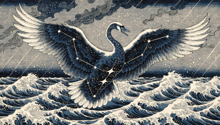


 a-medieval-manuscript-illustration-of-a-queen-seat.jpg


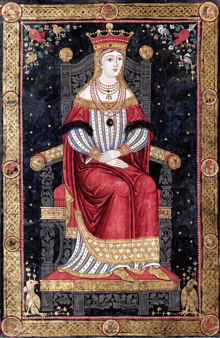


 a-persian-miniature-painting-of-a-young-cupbearer-.jpg


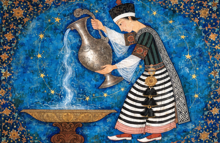


 a-roman-fresco-of-a-robed-goddess-holding-a-wheat-.jpg


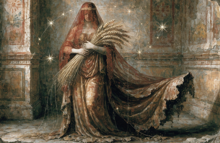


 a-roman-mosaic-of-an-eagle-with-spread-wings--tess.jpg


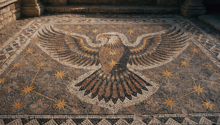


 a-russian-lubok-woodcut-print-of-a-large-bear---bo.jpg


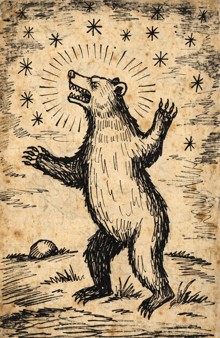


 a-scorpion-shape-outlined-with-bright-stars--const (1).jpg


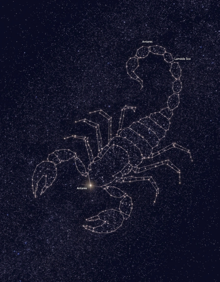

Test image: a-japanese-woodblock-print-of-a-swan-in-flight--uk.jpg


In [26]:
import zipfile
from pathlib import Path
from PIL import Image
from IPython.display import display

zip_path = Path("/content/image_rag_pictures.zip")

if not zip_path.exists():
    raise FileNotFoundError(
        "Файл /content/image_rag_pictures.zip не найден. "
        "Загрузите image_rag_pictures.zip в Files слева в Colab."
    )

image_dir = Path("/content/image_rag_pictures")
image_dir.mkdir(parents=True, exist_ok=True)

# Распаковываем архив
with zipfile.ZipFile(zip_path, "r") as zf:
    zf.extractall(image_dir)


image_paths = sorted([
    p for p in image_dir.rglob("*")
    if p.suffix.lower() in {".jpg", ".jpeg", ".png", ".webp"}
])

if len(image_paths) == 0:
    raise FileNotFoundError(
        "После распаковки не найдено изображений. "
        "Проверьте, что внутри архива есть .jpg/.jpeg/.png/.webp файлы."
    )

print(f"Found images: {len(image_paths)}")
for p in image_paths:
    print("-", p.relative_to(image_dir))

#  7 изображений для тестирования
selected_image_paths = image_paths[:7]

if len(selected_image_paths) < 7:
    print(f"Warning: найдено только {len(selected_image_paths)} изображений, а ожидалось 7.")

selected_images = []

for path in selected_image_paths:
    img = Image.open(path).convert("RGB")
    selected_images.append((path, img))

#  выбранные картинки
for path, img in selected_images:
    print("\n", path.name)
    display(img.resize((220, int(220 * img.height / img.width))))

# Тестовая картинка
test_path, test_image = selected_images[0]
print("Test image:", test_path.name)

In [28]:
# Сравнение unconditional и conditional captioning для одного изображения
caption_uncond = generate_caption(test_image)
print(f'[Unconditional]: {caption_uncond}')

# Conditional: подсказываем тематический префикс, который помогает направить модель к теме созвездий
caption_cond_1 = generate_caption(test_image, conditional_prompt='the constellation')
print(f'[Conditional 1]: {caption_cond_1}')

caption_cond_2 = generate_caption(test_image, conditional_prompt='a historical artwork representing the constellation')
print(f'[Conditional 2]: {caption_cond_2}')

# Генерируем captions
caption_rows = []
for path, img in selected_images:
    uncond = generate_caption(img)
    cond_1 = generate_caption(img, conditional_prompt='the constellation')
    cond_2 = generate_caption(img, conditional_prompt='a historical artwork representing the constellation')
    caption_rows.append({
        'image': path.name,
        'unconditional': uncond,
        'conditional_constellation': cond_1,
        'conditional_artwork': cond_2,
    })

captions_df = pd.DataFrame(caption_rows)
display(captions_df)

[Unconditional]: an image of a bird flying over the ocean
[Conditional 1]: the constellation of the great white swan
[Conditional 2]: a historical artwork representing the constellations of the great white swan


,image,unconditional,conditional_constellation,conditional_artwork
0,a-japanese-woodblock-print-of-a-swan-in-flight...,an image of a bird flying over the ocean,the constellation of the great white swan,a historical artwork representing the constell...
1,a-medieval-manuscript-illustration-of-a-queen-...,a painting of a woman in a red dress sitting o...,"the constellation of venus, from a 15th - cent...",a historical artwork representing the constell...
2,a-persian-miniature-painting-of-a-young-cupbea...,a painting of a woman pouring water from a pot,"the constellation, a painting of a woman pouri...",a historical artwork representing the constell...
3,a-roman-fresco-of-a-robed-goddess-holding-a-wh...,a painting of a woman holding a bunch of wheat,the constellations of jupiter by john william tis,a historical artwork representing the constell...
4,a-roman-mosaic-of-an-eagle-with-spread-wings--...,a mosaic with a bird on it ' s back,the constellation mosaic on the floor of the h...,a historical artwork representing the constell...
5,a-russian-lubok-woodcut-print-of-a-large-bear-...,a black and white drawing of a bear,"the constellation of the bear, from the book o...",a historical artwork representing the constell...
6,a-scorpion-shape-outlined-with-bright-stars--c...,a constellation constellation with stars in th...,the constellation constellation in the night sky,a historical artwork representing the constell...


### Вопросы: анализ качества caption

Запустите captioning на выбранных изображениях и сравните:
1. Оцените качество генерации caption с помощью BLIP для выбранных изображений
2. Помогает ли conditional prompt? В каких случаях?
3. Сравните два conditional prompts для нескольких изображений и оцените, какой сработал лучше всего в каких случаях.



BLIP в целом хорошо описывает простые визуальные изображения: животных, фигуры, главные объекты. Модель видит изображение, но не очень хорошо  понимает их астрономический смысл.
Conditional prompt помогает, когда изображение связано с мифологическим образом созвездия (подсказка "the constellation" заставляет модель описывать картинку в терминах созвездий) Это полезно для Image-RAG, тк подпись становится ближе к текстам из базы.
Промпт "the constellation" обычно приводит к более коротким и прямым описаниям, промпт "a historical artwork representing the constellation" лучше подходит для картинок в стиле миниатюр или старых иллюстраций, потому что лучше учитывает художественный стиль.

## 2.2. Полный pipeline `image_rag_query`

Соединяем всё: картинка → BLIP caption → caption как запрос к Chroma → найденный контекст + caption + вопрос пользователя → ответ LLM.




####################################################################################################
IMAGE: a-japanese-woodblock-print-of-a-swan-in-flight--uk.jpg


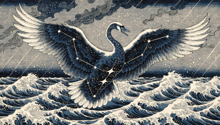

Both `max_new_tokens` (=180) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


[BLIP caption]: the constellation of the great white swan
--------------------------------------------------------------------------------
QUESTION: Which constellation is most likely represented in this image?
ANSWER:
The constellation most likely represented in this image is Cygnus.
SOURCES:
- Pegasus | chunk=27 | External links  The Deep Photographic Guide to the Constellations: Pegasus The clickable Pegasus Star Tales – Pegasus Warburg Institute Iconographic D...
- Pegasus | chunk=6 | Characteristics Covering 1121 square degrees, Pegasus is the seventh-largest of the 88 constellations. Pegasus is bordered by Andromeda to the north a...
- Cygnus | chunk=0 | Cygnus is a northern constellation on the plane of the Milky Way, deriving its name from the Latinized Greek word for "swan". Cygnus is one of the mos...
- Orion | chunk=43 | Depictions In artistic renderings, the surrounding constellations are sometimes related to Orion: he is depicted standing next to the river Eridanus w...

#

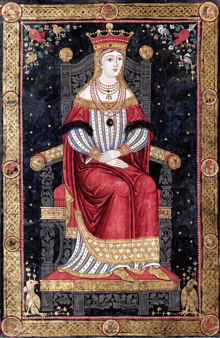

Both `max_new_tokens` (=180) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


[BLIP caption]: the constellation of venus, from a 15th - century manuscript, showing a portrait of a woman in a red dress and a gold crown
--------------------------------------------------------------------------------
QUESTION: Which constellation is most likely represented in this image?
ANSWER:
venus
SOURCES:
- Pegasus | chunk=27 | External links  The Deep Photographic Guide to the Constellations: Pegasus The clickable Pegasus Star Tales – Pegasus Warburg Institute Iconographic D...
- Perseus | chunk=33 | External links  The Deep Photographic Guide to the Constellations: Perseus The clickable Perseus Warburg Institute Iconographic Database (medieval and...
- Cassiopeia | chunk=4 | Cassiopeia has been variously portrayed throughout her history as a constellation. In Persia, she was drawn by al-Sufi as a queen holding a staff with...
- Cygnus | chunk=42 | External links  The Deep Photographic Guide to the Constellations: Cygnus Northern Cygnus Mosaic Pan and Zoom in on deep sky obje

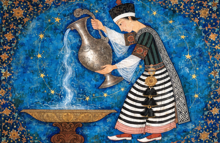

Both `max_new_tokens` (=180) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


[BLIP caption]: the constellation, a painting of a woman pouring water from a jug
--------------------------------------------------------------------------------
QUESTION: Which constellation is most likely represented in this image?
ANSWER:
The constellation most likely represented in this image is Aquarius.
SOURCES:
- Aquarius | chunk=4 | In the Greek tradition, the constellation came to be represented simply as a single vase from which a stream poured down to Piscis Austrinus. The name...
- Aquarius | chunk=6 | Depictions In the first century, Ptolemy's Almagest established the common Western depiction of Aquarius. It pours water in a stream of more than 20 s...
- Orion | chunk=43 | Depictions In artistic renderings, the surrounding constellations are sometimes related to Orion: he is depicted standing next to the river Eridanus w...
- Ursa Major | chunk=35 | In culture Ursa Major is mentioned by such poets as Homer, Spenser, Shakespeare, Tennyson and also by Federico Garcia Lorca,

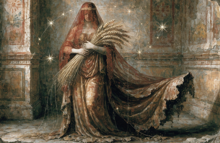

Both `max_new_tokens` (=180) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


[BLIP caption]: the constellations of jupiter by john william tis
--------------------------------------------------------------------------------
QUESTION: Which constellation is most likely represented in this image?
ANSWER:
Ursa Major
SOURCES:
- Perseus | chunk=33 | External links  The Deep Photographic Guide to the Constellations: Perseus The clickable Perseus Warburg Institute Iconographic Database (medieval and...
- Cassiopeia | chunk=39 | External links  The Deep Photographic Guide to the Constellations: Cassiopeia The clickable Cassiopeia Star Tales – Cassiopeia Warburg Institute Icono...
- Scorpius | chunk=13 | External links  The Deep Photographic Guide to the Constellations: Scorpius The clickable Scorpius Star Tales – Scorpius Warburg Institute Iconographi...
- Ursa Major | chunk=39 | External links  The Deep Photographic Guide to the Constellations: Ursa Major The clickable Ursa Major Archived 2022-06-20 at the Wayback Machine AAVS...

#####################################

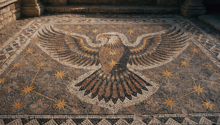

Both `max_new_tokens` (=180) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


[BLIP caption]: the constellation mosaic on the floor of the house of the fage
--------------------------------------------------------------------------------
QUESTION: Which constellation is most likely represented in this image?
ANSWER:
Cygnus
SOURCES:
- Cygnus | chunk=42 | External links  The Deep Photographic Guide to the Constellations: Cygnus Northern Cygnus Mosaic Pan and Zoom in on deep sky objects in Cygnus (requir...
- Orion | chunk=43 | Depictions In artistic renderings, the surrounding constellations are sometimes related to Orion: he is depicted standing next to the river Eridanus w...
- Scorpius | chunk=13 | External links  The Deep Photographic Guide to the Constellations: Scorpius The clickable Scorpius Star Tales – Scorpius Warburg Institute Iconographi...
- Pegasus | chunk=27 | External links  The Deep Photographic Guide to the Constellations: Pegasus The clickable Pegasus Star Tales – Pegasus Warburg Institute Iconographic D...


In [31]:
def image_rag_query(
    image: Image.Image,
    user_question: str,
    conditional_prompt: str = 'the constellation',
    k: int = 4,
    verbose: bool = True,
) -> Dict:
    """Мультимодальный RAG: картинка → caption → retrieval → ответ LLM."""
    # Шаг 1: BLIP делает caption картинки
    caption = generate_caption(image, conditional_prompt=conditional_prompt)
    if verbose:
        print(f'[BLIP caption]: {caption}')

    # Шаг 2: caption + вопрос становятся запросом к Chroma
    retrieval_query = f'{caption}. {user_question}'
    retrieved_docs = vectorstore.similarity_search(retrieval_query, k=k)

    # Шаг 3: склеиваем контекст
    context = '\n\n'.join(
        [
            f"[Source: {doc.metadata['constellation']}, chunk {doc.metadata['chunk_id']}]\n{doc.page_content}"
            for doc in retrieved_docs
        ]
    )

    # Шаг 4: формируем кастомный промпт для Image-RAG
    messages = [
        {
            'role': 'system',
            'content': (
                'You are a multimodal RAG assistant. You cannot see the image directly. '
                'You only know the BLIP caption and the retrieved Wikipedia context. '
                'Answer the user question using only this information. '
                'If the caption or context is not enough, say that the answer is uncertain.'
            )
        },
        {
            'role': 'user',
            'content': (
                f'BLIP caption of the image:\n{caption}\n\n'
                f'Retrieved context:\n{context}\n\n'
                f'User question about the image: {user_question}\n\n'
                'Answer:'
            )
        }
    ]

    prompt = tokenizer.apply_chat_template(
        messages,
        tokenize=False,
        add_generation_prompt=True,
    )
    output = llm_pipeline(prompt)
    answer = output[0]['generated_text'].strip()

    result = {
        'caption': caption,
        'question': user_question,
        'answer': answer,
        'sources': [
            {
                'constellation': doc.metadata['constellation'],
                'source': doc.metadata['source'],
                'chunk_id': doc.metadata['chunk_id'],
                'preview': doc.page_content[:150].replace('\n', ' ') + '...',
            }
            for doc in retrieved_docs
        ]
    }

    if verbose:
        print('-' * 80)
        print(f'QUESTION: {user_question}')
        print(f'ANSWER:\n{answer}')
        print('SOURCES:')
        for s in result['sources']:
            print(f"- {s['constellation']} | chunk={s['chunk_id']} | {s['preview']}")

    return result

# 5 вопросов для тестирования Image-RAG
image_questions = [
    'Which constellation is most likely represented in this image?',
    'What mythological figure or animal is connected with this constellation?',
    'Is this constellation part of the zodiac?',
    'What is one notable star or deep-sky object connected with this constellation?',
    'How confident should we be based on the caption and retrieved context?',
]

# Тестируем на нескольких изображениях. Для экономии времени можно уменьшить [:3] до [:1].
image_rag_results = []
for path, img in selected_images[:5]:
    print('\n' + '#' * 100)
    print('IMAGE:', path.name)
    display(img.resize((220, int(220 * img.height / img.width))))
    question = image_questions[0]
    image_rag_results.append(image_rag_query(img, question, k=4, verbose=True))

### Вопросы: анализ качества Image RAG

1. Всегда ли caption приводит Image RAG к нужному созвездию?
2. Что произойдёт, если BLIP неправильно классифицирует картинку?


1 - Caption не всегда приводит к правильному созвездию. Если BLIP правильно распознаёт ключевой образ, обычно находятся релевантные статьи, в ином случае поиск может уйти к неправильному созвездию.

2 - качество Image-RAG сильно зависит от качества полписей. Если BLIP неправильно классифицирует картинку, ошибка передаётся дальше во весь пайплайн: неверный caption используется как поисковый запрос, находятся нерелевантные чанки, а ответы строятся на неправильном контексте.  

## Сhallenge: MultiQueryRetriever

Ручные формулировки вопросов работают, но иногда retrieval промахивается, потому что в чанках формулировка другая. `MultiQueryRetriever` решает эту проблему так: он просит LLM **перефразировать вопрос несколькими способами**, делает retrieval для каждой версии и объединяет результаты. В данном challenge вам необходимо сравнить ручной подход к перефразированию запросов для обычного RAG (не Image RAG) и встроенный в langchain.

**Пример:**

*Which constellation contains a famous red supergiant nearing the end of its life?*

В чанках нет "red supergiant" напрямую в контексте Ориона, нужно связать тип звезды с названием
    

Что необходимо сделать:

1.   Функция генерации перефразировок

Напишите функцию `generate_query_variants(question: str, n: int = 3) -> List[str]`, которая:

*   Формирует сообщения в chat-формате (system + user) для Qwen
*   В system prompt объясняет модели задачу: сгенерировать n разных формулировок одного и того же вопроса
*   В user сообщении передаёт исходный вопрос и просит вернуть ровно n вариантов, каждый на отдельной строке, без нумерации и пояснений
*   Прогоняет через llm_pipeline и парсит ответ: разбивает по \n, фильтрует пустые строки, возвращает список строк

2.   Функция `multiquery retrieval`

Напишите функцию multiquery_retrieve(question: str, n_variants: int = 3, k: int = 3) -> List[Document], которая:


*   Вызывает generate_query_variants чтобы получить n_variants перефразировок
*   Добавляет к ним исходный вопрос (итого n_variants + 1 запросов)
*   Для каждого запроса делает vectorstore.similarity_search(query, k=k)
*   Объединяет все найденные документы в один список
*   Убирает дубликаты. Oдин и тот же чанк мог найтись по нескольким вариантам запроса, поэтому стоит проверять
*   Возвращает список уникальных документов

3.   Полный pipeline
Напишите функцию `rag_query_multiquery(...)`

4.   Подключите **MultiQueryRetriever** из LangChain

Документация: https://python.langchain.com/docs/how_to/MultiQueryRetriever/

Вам понадобится:
*   импортировать MultiQueryRetriever из langchain.retrievers
*   обернуть llm_pipeline в HuggingFacePipeline из langchain_huggingface, так как LangChain не работает напрямую с HF pipeline
*   создать `MultiQueryRetriever.from_llm(retriever=..., llm=...)`
*   Включите логирование, чтобы видеть сгенерированные перефразировки

5. Ответьте кратко на вопросы

*   Одинаковые ли варианты с перефразированием генерирует Qwen в вашей реализации и в LangChain? Если разные, то предположите, по какой причине.
*   Как LangChain делает дедупликацию? Это отличается от вашего подхода?
*   Какой вариант даёт больше уникальных чанков и почему?
*   В каком сценарии вы бы выбрали свою реализацию вместо готовой из LangChain?





















